# Task 3: Clustering: Gaussian Mixture Models

Libraries:

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Load data:

In [19]:
X_clustering = pd.read_csv("../data/03_selected/clustering_features.csv")
X_clustering.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 22 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   thal_3     303 non-null    float64
 1   thal_7     303 non-null    float64
 2   cp_4       303 non-null    float64
 3   is_exang   303 non-null    float64
 4   ca         303 non-null    float64
 5   slope_1    303 non-null    float64
 6   slope_2    303 non-null    float64
 7   thalach    303 non-null    float64
 8   oldpeak    303 non-null    float64
 9   is_male    303 non-null    float64
 10  cp_3       303 non-null    float64
 11  age        303 non-null    float64
 12  cp_2       303 non-null    float64
 13  restecg_2  303 non-null    float64
 14  restecg_0  303 non-null    float64
 15  cp_1       303 non-null    float64
 16  thal_6     303 non-null    float64
 17  chol       303 non-null    float64
 18  trestbps   303 non-null    float64
 19  slope_3    303 non-null    float64
 20  restecg_1  303 non-nu

In [13]:
X_pca = pd.read_csv("../data/03_selected/pca_projection.csv")
X_pca.head()

,PC1,PC2,target
0,-1.561300,-2.075091,0
1,-3.067305,-1.923260,1
2,-3.749194,-0.046765,1
3,1.473170,0.812834,0
4,2.635836,-1.300294,0


C:\Users\hidal\AppData\Local\Temp\ipykernel_13584\1801078437.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


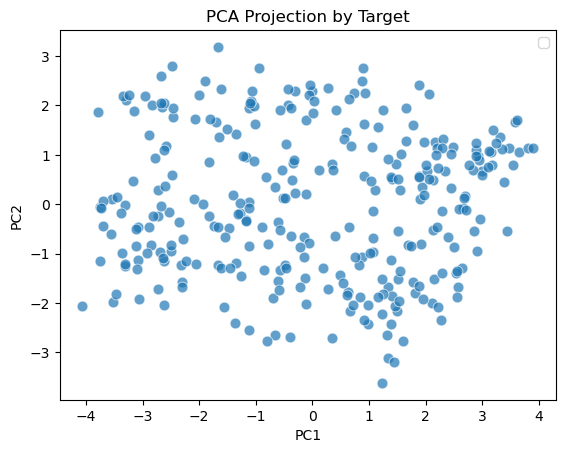

In [14]:
plt.figure()

# Plot each class separately
sns.scatterplot(
    x=X_pca["PC1"],
    y=X_pca["PC2"],
    s = 60,
    alpha = 0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection by Target")
plt.legend()
plt.show()

### 3.1 Fit GGMs with a varying number of components (2 to 10)

In [15]:
n_components_range = range(2,11)

bic_scores = []
aic_scores = []

for n_components in n_components_range:
    # Set up model
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='full', # each cluster its own elliptical shape
        init_params='random', # initialize weights randomly (defaul = KMeans)
        random_state=42 # fix the random seed
    )

    # Fit the model
    gmm.fit(X_clustering)

    # Compute and save BIC and AIC
    bic_scores.append(gmm.bic(X_clustering))
    aic_scores.append(gmm.aic(X_clustering))

### 3.2 Use BIC or AIC to select the optimal number of components

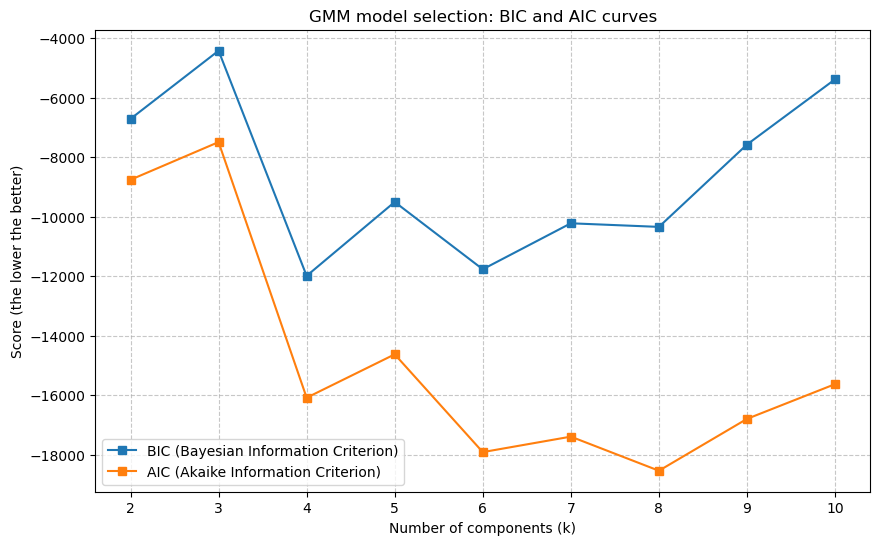

In [16]:
# Plot
plt.figure(figsize=(10,6))
plt.plot(n_components_range, bic_scores, marker = 's', label = 'BIC (Bayesian Information Criterion)')
plt.plot(n_components_range, aic_scores, marker = 's', label = 'AIC (Akaike Information Criterion)')

plt.title('GMM model selection: BIC and AIC curves')
plt.xlabel('Number of components (k)')
plt.ylabel('Score (the lower the better)')
plt.xticks(n_components_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 3.3 Visualise cluster assignments by projecting the data into PCA space (2D)

PCA:

NameError: name 'pca' is not defined

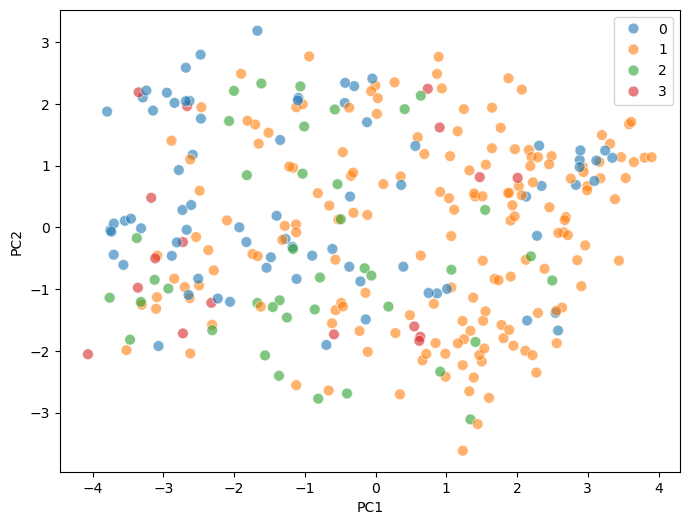

In [18]:
# Select best k and adjust the final model
best_k = 4
gmm_best = GaussianMixture(
    n_components=best_k,
    covariance_type='full',
    init_params='random',
    random_state=42
    
)
gmm_best.fit(X_clustering)
gmm_labels = gmm_best.predict(X_clustering)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca["PC1"],
    y=X_pca["PC2"],
    hue=gmm_labels,
    palette='tab10',
    s=60,
    alpha=0.6
)

centroids_pca = pca.transform(gmm_best.means_)
sns.scatterplot(
    x=centroids_pca[:, 0],
    y=centroids_pca[:, 1],
    hue=range(best_k),
    palette='tab10',
    marker="X",
    s=200,
    legend=False
)

plt.title(f"GGM assignments (k={best_k}) in PCA space (2D)")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend()
plt.tight_layout()
plt.show()

### 3.4 Compare the hard cluster assignments from GMM with K-Means